In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
from deep_sort_realtime.deepsort_tracker import DeepSort



/Users/kranthi/Documents/Projects/FADS Project/FP_Tracing_Application/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
video_path = "My Movie.mp4"  # Update with actual path
floor_plan_path = "FloorPlan.png"  # Update with actual path
print(video_path)

My Movie.mp4


In [3]:
floor_plan = cv2.imread(floor_plan_path)
floor_plan = cv2.cvtColor(floor_plan, cv2.COLOR_BGR2RGB)  # Convert for Matplotlib

In [4]:
# Load the floor plan image
floor_plan = cv2.imread(floor_plan_path)
floor_plan = cv2.cvtColor(floor_plan, cv2.COLOR_BGR2RGB)

In [8]:
# Load YOLO model (use pre-trained weights)
yolo = YOLO("yolov8n.pt")  # Use 'yolov5s.pt' for YOLOv5

# Initialize DeepSORT tracker
deep_sort = DeepSort()

In [9]:
cap = cv2.VideoCapture(video_path)
if not cap.isOpened():
    raise Exception("Error: Could not open video file.")

user_path = []


In [13]:
while True:
    ret, frame = cap.read()
    if not ret:
        break
    
    # Detect objects using YOLO
    results = yolo(frame)
    detections = []
    
    # Extract person detections
    for result in results:
        for box in result.boxes:
            box_data = box.xyxy.cpu().numpy().flatten()
            if len(box_data) >= 4:  # Ensure there are enough values
                x1, y1, x2, y2 = box_data[:4]
                conf = box.conf.item() if hasattr(box, 'conf') else 1.0  # Set default confidence if missing
                cls = box.cls.item() if hasattr(box, 'cls') else 0  # Default to class 0 if missing
                
                if int(cls) == 0:  # Class 0 corresponds to 'person' in COCO dataset
                    detections.append(([x1, y1, x2, y2], conf, int(cls)))
    
    # Track user movement
    tracks = deep_sort.update_tracks(detections, frame=frame)
    
    for track in tracks:
        if track.is_confirmed() and track.get_det_class() == 0:  # Confirmed person track
            x1, y1, x2, y2 = track.to_tlbr()
            cx = int((x1 + x2) / 2)
            cy = int((y1 + y2) / 2)
            user_path.append((cx, cy))

cap.release()
user_path = np.array(user_path)



0: 384x640 (no detections), 71.4ms
Speed: 2.0ms preprocess, 71.4ms inference, 0.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 36.1ms
Speed: 0.8ms preprocess, 36.1ms inference, 0.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 29.3ms
Speed: 0.9ms preprocess, 29.3ms inference, 0.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 29.0ms
Speed: 1.1ms preprocess, 29.0ms inference, 0.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 30.5ms
Speed: 0.8ms preprocess, 30.5ms inference, 0.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 34.0ms
Speed: 1.0ms preprocess, 34.0ms inference, 0.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 32.8ms
Speed: 0.8ms preprocess, 32.8ms inference, 0.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 33.6ms
Speed: 0.8ms preprocess, 33.6ms i

KeyboardInterrupt: 

In [ ]:
# Normalize and map to floor plan
if user_path.size > 0:
    x_min, y_min = user_path.min(axis=0)
    x_max, y_max = user_path.max(axis=0)
    
    x_range = x_max - x_min if x_max - x_min != 0 else 1
    y_range = y_max - y_min if y_max - y_min != 0 else 1
    
    height, width, _ = floor_plan.shape
    norm_path = np.array([
        ((x - x_min) / x_range * width, (y - y_min) / y_range * height)
        for x, y in user_path
    ]).astype(int)
    
    # Smooth the path using a moving average filter
    window_size = 5
    smoothed_path = np.convolve(norm_path[:, 0], np.ones(window_size)/window_size, mode='valid'), \
                     np.convolve(norm_path[:, 1], np.ones(window_size)/window_size, mode='valid')
    norm_path = np.column_stack(smoothed_path).astype(int)
    
    for i in range(1, len(norm_path)):
        cv2.line(floor_plan, tuple(norm_path[i - 1]), tuple(norm_path[i]), (255, 0, 0), 3)


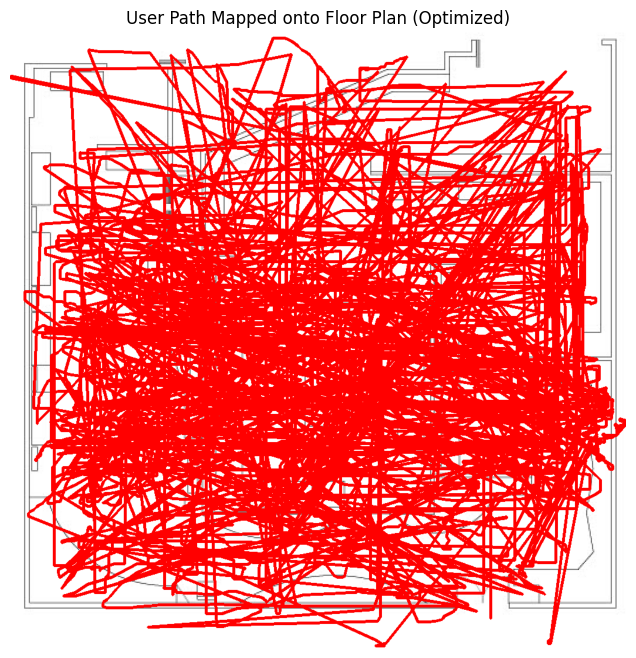

In [ ]:
# Display final visualization
plt.figure(figsize=(10, 8))
plt.imshow(floor_plan)
plt.title("User Path Mapped onto Floor Plan (AI Tracking)")
plt.axis("off")
plt.show()


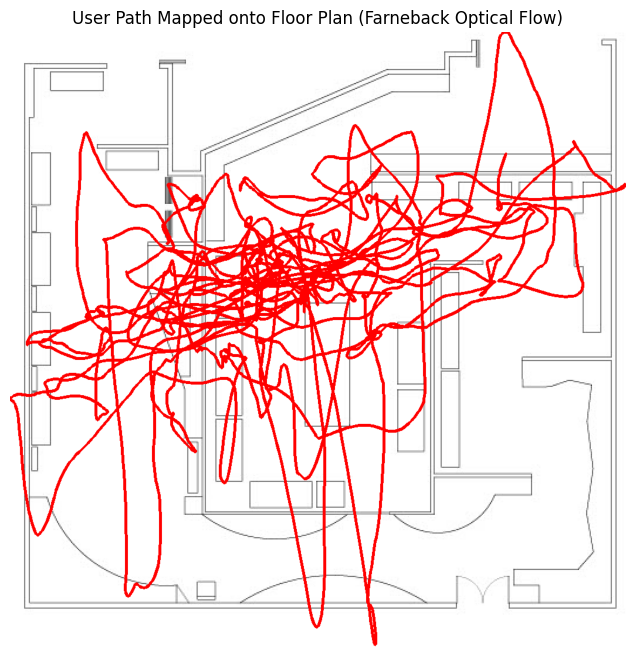

In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# Paths to input files (UPDATE THESE PATHS)
video_path = "My Movie.mp4"  # Update with actual path
floor_plan_path = "FloorPlan.png"  # Update with actual path

# Load the floor plan image
floor_plan = cv2.imread(floor_plan_path)
floor_plan = cv2.cvtColor(floor_plan, cv2.COLOR_BGR2RGB)  # Convert for Matplotlib

cap = cv2.VideoCapture(video_path)
if not cap.isOpened():
    raise Exception("Error: Could not open video file.")

# Read the first frame
ret, prev_frame = cap.read()
if not ret:
    raise Exception("Error: Could not read first frame from video.")

prev_gray = cv2.cvtColor(prev_frame, cv2.COLOR_BGR2GRAY)

# Store movement path
user_path = [(0, 0)]  # Start at origin
scale_factor = 5  # Increase movement effect for better visualization

while True:
    ret, frame = cap.read()
    if not ret:
        break
    
    gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    
    # Use Farneback Optical Flow for dense motion tracking
    flow = cv2.calcOpticalFlowFarneback(prev_gray, gray_frame, None, 0.5, 3, 15, 3, 5, 1.2, 0)
    
    # Compute average motion vector
    movement_vector = np.mean(flow, axis=(0, 1)) * scale_factor
    user_path.append((user_path[-1][0] + movement_vector[0], user_path[-1][1] + movement_vector[1]))
    
    prev_gray = gray_frame.copy()

cap.release()
user_path = np.array(user_path)

# Normalize and map to floor plan
if user_path.size > 0:
    x_min, y_min = user_path.min(axis=0)
    x_max, y_max = user_path.max(axis=0)
    
    x_range = x_max - x_min if x_max - x_min != 0 else 1
    y_range = y_max - y_min if y_max - y_min != 0 else 1
    
    height, width, _ = floor_plan.shape
    norm_path = np.array([
        ((x - x_min) / x_range * width, (y - y_min) / y_range * height)
        for x, y in user_path
    ]).astype(int)
    
    # Smooth the path using a Gaussian filter to avoid artifacts
    
    norm_path[:, 0] = gaussian_filter1d(norm_path[:, 0], sigma=2)
    norm_path[:, 1] = gaussian_filter1d(norm_path[:, 1], sigma=2)
    
    for i in range(1, len(norm_path)):
        cv2.line(floor_plan, tuple(norm_path[i - 1]), tuple(norm_path[i]), (255, 0, 0), 3)

# Display final visualization
plt.figure(figsize=(10, 8))
plt.imshow(floor_plan)
plt.title("User Path Mapped onto Floor Plan (Farneback Optical Flow)")
plt.axis("off")
plt.show()

